# CardioIA — Fase 6: Modelo Preditivo de Pico de Risco Cardíaco

**FIAP — 2TIAOR20242**

**Execução local:** use o ambiente virtual do projeto (`pip install -r requirements.txt` e `pip install -r requirements-notebook.txt`), abra este ficheiro no **VS Code** (extensão Jupyter) ou no **Jupyter Notebook**, selecione o kernel do `venv` e execute todas as células. O modelo é gravado em `../ml/modelo_risco_cardiaco.joblib` (pasta `ml/` na raiz do repositório).

Este notebook implementa a **Parte 1** da Fase 6:
- Geração do dataset sintético de pacientes cardiológicos
- Treinamento de modelo supervisionado para prever `pico_risco`
- Avaliação com métricas (acurácia, matriz de confusão)
- Persistência do modelo treinado
- Simulação de previsão para novo paciente

## 1. Imports e Configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Imports concluídos')

✅ Imports concluídos


## 2. Geração do Dataset Sintético

Criamos 1000 registros simulados com características clínicas cardiológicas.

**Features:**
- `idade`: idade do paciente (anos)
- `freq_cardiaca`: frequência cardíaca (bpm)
- `spo2`: saturação de oxigênio (%)
- `carga_sistema`: carga do sistema de monitoramento (0–1)
- `disponibilidade_recursos`: recursos hospitalares disponíveis (0–1)

**Target:** `pico_risco` (0 = sem pico, 1 = pico de risco detectado)

In [2]:
N = 1000

idade = np.clip(np.random.normal(55, 15, N).astype(int), 18, 90)
freq_cardiaca = np.clip(np.random.normal(80, 20, N).astype(int), 40, 200)
spo2 = np.clip(np.random.normal(96, 3, N), 80.0, 100.0).round(1)
carga_sistema = np.clip(np.random.uniform(0.1, 1.0, N), 0.0, 1.0).round(2)
disponibilidade_recursos = np.clip(np.random.uniform(0.1, 1.0, N), 0.0, 1.0).round(2)

# Regra heurística: pico_risco = 1 quando sinais clínicos críticos + sistema sob pressão
condicao_clinica = (freq_cardiaca > 100) | (spo2 < 93)
condicao_sistema = (carga_sistema > 0.7) | (disponibilidade_recursos < 0.3)
pico_risco_base = (condicao_clinica & condicao_sistema).astype(int)

# Ruído realista (10%): inverte alguns rótulos para simular variabilidade clínica
ruido = np.random.random(N) < 0.1
pico_risco = np.where(ruido, 1 - pico_risco_base, pico_risco_base)

df = pd.DataFrame({
    'idade': idade,
    'freq_cardiaca': freq_cardiaca,
    'spo2': spo2,
    'carga_sistema': carga_sistema,
    'disponibilidade_recursos': disponibilidade_recursos,
    'pico_risco': pico_risco
})

print(f'Dataset gerado: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dataset gerado: 1000 linhas × 6 colunas


,idade,freq_cardiaca,spo2,carga_sistema,disponibilidade_recursos,pico_risco
0,62,107,94.0,0.84,0.92,1
1,52,98,95.6,0.99,0.27,0
2,64,81,93.6,0.33,0.84,0
3,77,67,95.1,0.97,0.59,1
4,51,93,90.3,0.49,0.17,1
5,51,87,96.6,0.41,0.96,0
6,78,97,96.0,0.15,0.32,0
7,66,92,93.5,0.15,0.87,0
8,47,100,98.0,0.72,0.25,0
9,63,69,98.8,0.51,0.87,0


## 3. Análise Exploratória

=== Estatísticas Descritivas ===
         idade  freq_cardiaca     spo2  carga_sistema  \
count  1000.00        1000.00  1000.00        1000.00   
mean     54.77          81.09    95.89           0.54   
std      14.47          19.49     2.71           0.26   
min      18.00          40.00    86.90           0.10   
25%      45.00          67.00    94.10           0.32   
50%      55.00          81.00    96.00           0.54   
75%      64.00          94.00    98.00           0.76   
max      90.00         143.00   100.00           1.00   

       disponibilidade_recursos  pico_risco  
count                   1000.00     1000.00  
mean                       0.55        0.22  
std                        0.26        0.41  
min                        0.10        0.00  
25%                        0.33        0.00  
50%                        0.54        0.00  
75%                        0.77        0.00  
max                        1.00        1.00  

=== Distribuição do Target pico_risco 

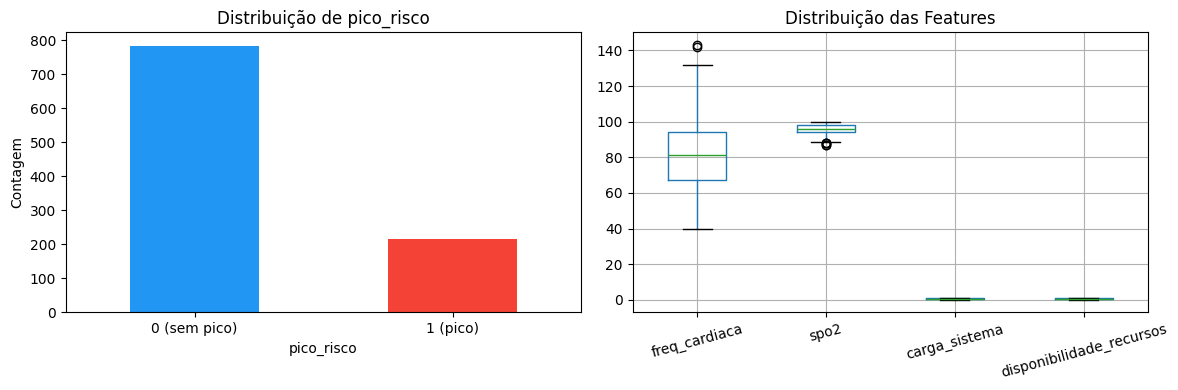

In [3]:
print('=== Estatísticas Descritivas ===')
print(df.describe().round(2))

print('\n=== Distribuição do Target pico_risco ===')
contagem = df['pico_risco'].value_counts()
print(contagem)
print(f'Proporção de picos: {contagem[1]/len(df)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contagem.plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'])
axes[0].set_title('Distribuição de pico_risco')
axes[0].set_xlabel('pico_risco')
axes[0].set_ylabel('Contagem')
axes[0].set_xticklabels(['0 (sem pico)', '1 (pico)'], rotation=0)

features = ['freq_cardiaca', 'spo2', 'carga_sistema', 'disponibilidade_recursos']
df.boxplot(column=features, ax=axes[1])
axes[1].set_title('Distribuição das Features')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 4. Treinamento do Modelo

In [4]:
FEATURES = ['idade', 'freq_cardiaca', 'spo2', 'carga_sistema', 'disponibilidade_recursos']
TARGET = 'pico_risco'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print(f'Distribuição treino — 0: {sum(y_train==0)} | 1: {sum(y_train==1)}')
print(f'Distribuição teste  — 0: {sum(y_test==0)} | 1: {sum(y_test==1)}')

modelo = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
modelo.fit(X_train, y_train)

print('\n✅ Modelo treinado com sucesso!')
print(f'Algoritmo: {type(modelo).__name__}')
print(f'Hiperparâmetros: n_estimators=100, random_state={RANDOM_STATE}')

Treino: 800 amostras | Teste: 200 amostras
Distribuição treino — 0: 627 | 1: 173
Distribuição teste  — 0: 157 | 1: 43



✅ Modelo treinado com sucesso!
Algoritmo: RandomForestClassifier
Hiperparâmetros: n_estimators=100, random_state=42


## 5. Avaliação do Modelo

=== Acurácia: 0.8750 (87.50%) ===

=== Relatório de Classificação ===
                   precision    recall  f1-score   support

     Sem Pico (0)       0.87      0.99      0.93       157
Pico de Risco (1)       0.95      0.44      0.60        43

         accuracy                           0.88       200
        macro avg       0.91      0.72      0.76       200
     weighted avg       0.88      0.88      0.86       200

=== Matriz de Confusão ===
Verdadeiros Negativos (TN): 156
Falsos Positivos    (FP):   1
Falsos Negativos    (FN):   24
Verdadeiros Positivos (TP): 19


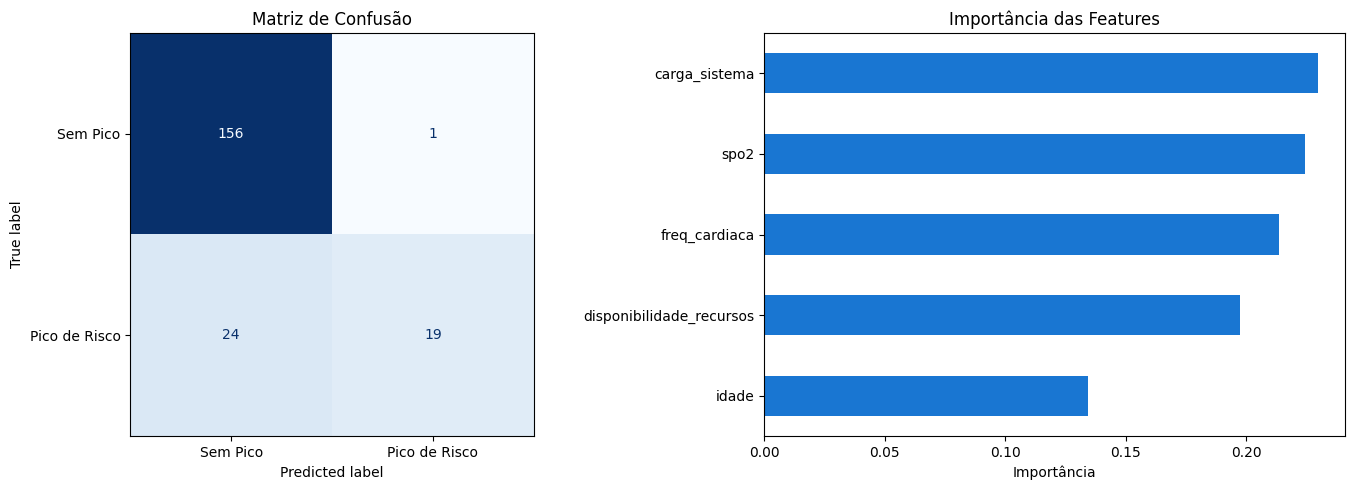

In [5]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

acuracia = accuracy_score(y_test, y_pred)
print(f'=== Acurácia: {acuracia:.4f} ({acuracia*100:.2f}%) ===')

print('\n=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=['Sem Pico (0)', 'Pico de Risco (1)']))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'=== Matriz de Confusão ===')
print(f'Verdadeiros Negativos (TN): {tn}')
print(f'Falsos Positivos    (FP):   {fp}')
print(f'Falsos Negativos    (FN):   {fn}')
print(f'Verdadeiros Positivos (TP): {tp}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Pico', 'Pico de Risco'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão')

importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=True)
importancias.plot(kind='barh', ax=axes[1], color='#1976D2')
axes[1].set_title('Importância das Features')
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.show()

## 6. Salvamento do Modelo

In [6]:
from pathlib import Path
import os

# Grava em ml/ na raiz do repositório (caminho relativo a notebooks/)
ml_dir = Path("..") / "ml"
ml_dir.mkdir(parents=True, exist_ok=True)
model_path = ml_dir / "modelo_risco_cardiaco.joblib"
joblib.dump(modelo, model_path)
print(f"✅ Modelo salvo em: {model_path.resolve()}")
print(f"   Tamanho: {os.path.getsize(model_path) / 1024:.1f} KB")

modelo_carregado = joblib.load(model_path)
assert accuracy_score(y_test, modelo_carregado.predict(X_test)) == acuracia
print("✅ Modelo recarregado e validado com sucesso!")
print("   (A Parte 2 lê este ficheiro via agents/config.py → MODEL_PATH)")

✅ Modelo salvo em: C:\Fiap\dev\2TIAOR20242-CardioIA-Fase6-Cap1\ml\modelo_risco_cardiaco.joblib
   Tamanho: 1760.8 KB
✅ Modelo recarregado e validado com sucesso!
   (A Parte 2 lê este ficheiro via agents/config.py → MODEL_PATH)


## 7. Simulação de Previsão — Novo Paciente

Criamos manualmente um registro clínico simulado para demonstrar o modelo em ação.

In [7]:
novo_paciente = {
    'idade': 65,
    'freq_cardiaca': 115,
    'spo2': 91.5,
    'carga_sistema': 0.85,
    'disponibilidade_recursos': 0.20
}

X_novo = pd.DataFrame([novo_paciente])
probabilidade = modelo.predict_proba(X_novo)[0][1]

if probabilidade < 0.3:
    classificacao = 'BAIXO'
    emoji = '🟢'
elif probabilidade < 0.7:
    classificacao = 'MÉDIO'
    emoji = '🟡'
else:
    classificacao = 'ALTO'
    emoji = '🔴'

print('=' * 55)
print('  PREVISÃO PARA NOVO PACIENTE')
print('=' * 55)
print(f'  Dados clínicos:')
for k, v in novo_paciente.items():
    print(f'    {k:<30} {v}')
print('-' * 55)
print(f'  Probabilidade de pico de risco: {probabilidade:.1%}')
print(f'  Classificação de risco: {emoji} {classificacao}')
print('=' * 55)
print()
print('⚠️  AVISO: Resultado gerado por sistema acadêmico simulado.')
print('   Não substitui avaliação médica profissional.')
print('   Em emergências, ligue para o SAMU (192).')

  PREVISÃO PARA NOVO PACIENTE
  Dados clínicos:
    idade                          65
    freq_cardiaca                  115
    spo2                           91.5
    carga_sistema                  0.85
    disponibilidade_recursos       0.2
-------------------------------------------------------
  Probabilidade de pico de risco: 93.0%
  Classificação de risco: 🔴 ALTO

⚠️  AVISO: Resultado gerado por sistema acadêmico simulado.
   Não substitui avaliação médica profissional.
   Em emergências, ligue para o SAMU (192).
